In [16]:
from initNotebook import initNotebook
initNotebook()
import json
from config.rootPath import getRootPath
import matplotlib.pyplot as plt

In [24]:
def plot_data(datapaths, figsize=(14, 3)):
    """Plot alpha series for one or many JSON files stacked vertically.
    `datapaths` may be a single relative path string or a list of relative path strings (relative to project root).
    `figsize` is (width, height_per_plot).
    """
    import json
    from datetime import datetime
    import matplotlib.dates as mdates
    from config.rootPath import getRootPath
    from pathlib import Path
    # Normalize to list
    if isinstance(datapaths, (str, Path)):
        datapaths = [str(datapaths)]
    parsed = []
    for dp in datapaths:
        path = getRootPath().joinpath(dp)
        with open(path, 'r') as f:
            data = json.load(f)
        dates = []
        alphas = []
        for entry in data:
            alpha = entry.get('alpha')
            day = entry.get('day')
            if alpha is None:
                continue
            # Try to parse common date formats; fall back to None
            dt = None
            if day:
                for fmt in ('%Y-%m-%d %H:%M:%S', '%Y-%m-%d'):
                    try:
                        dt = datetime.strptime(day, fmt)
                        break
                    except Exception:
                        continue
                if dt is None:
                    try:
                        dt = datetime.fromisoformat(day)
                    except Exception:
                        dt = None
            dates.append(dt)
            alphas.append(alpha)
        parsed.append((dp, dates, alphas))
    n = len(parsed)
    if n == 0:
        print('No valid files provided.')
        return
    # Create stacked subplots; make width larger and height proportional to number of plots
    width, h_per = figsize
    fig, axes = plt.subplots(n, 1, sharex=True, figsize=(width, h_per * n))
    if n == 1:
        axes = [axes]
    for ax, (dp, dates, alphas) in zip(axes, parsed):
        # If dates were parsed, use them; otherwise use index
        if any(d is not None for d in dates):
            # replace None with incremental indices to keep lengths aligned
            x = [d if d is not None else i for i, d in enumerate(dates)]
            ax.plot(x, alphas, marker='o', linestyle='-')
            locator = mdates.AutoDateLocator()
            formatter = mdates.ConciseDateFormatter(locator)
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(formatter)
        else:
            ax.plot(range(len(alphas)), alphas, marker='o', linestyle='-')
        ax.set_ylabel('Alpha')
        ax.set_title(Path(dp).name)
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.grid(True, alpha=0.3)
        # Increase x-axis tick label size a bit to make it 'bigger'
        ax.tick_params(axis='x', labelsize=10)
    axes[-1].set_xlabel('Date / Index')
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()

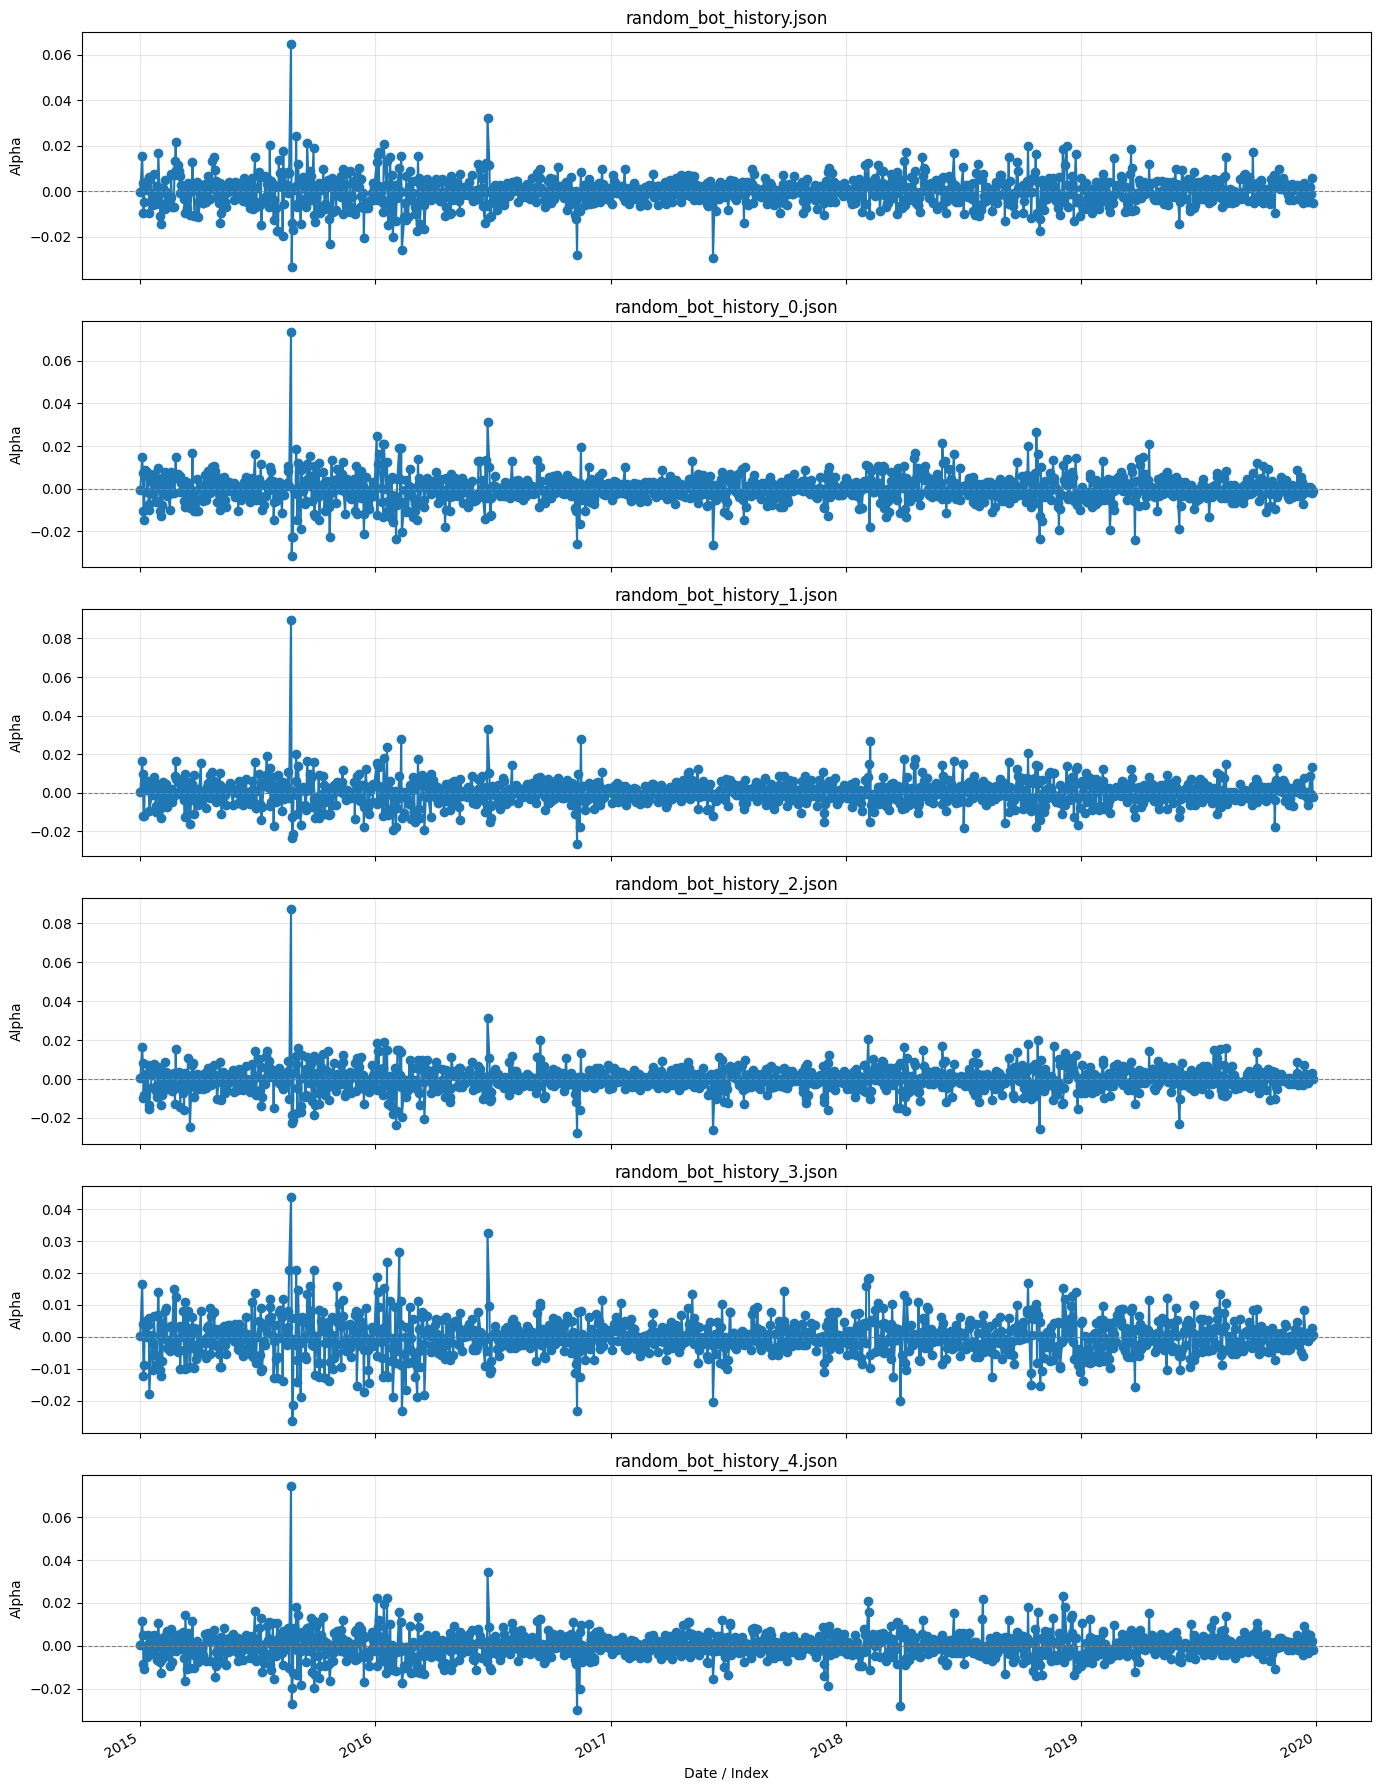

In [26]:
dataPaths = [
"data/random_bot_histories/random_bot_history.json",
"data/random_bot_histories/random_bot_history_0.json",
"data/random_bot_histories/random_bot_history_1.json",
"data/random_bot_histories/random_bot_history_2.json",
"data/random_bot_histories/random_bot_history_3.json",
"data/random_bot_histories/random_bot_history_4.json"
]
plot_data(dataPaths)

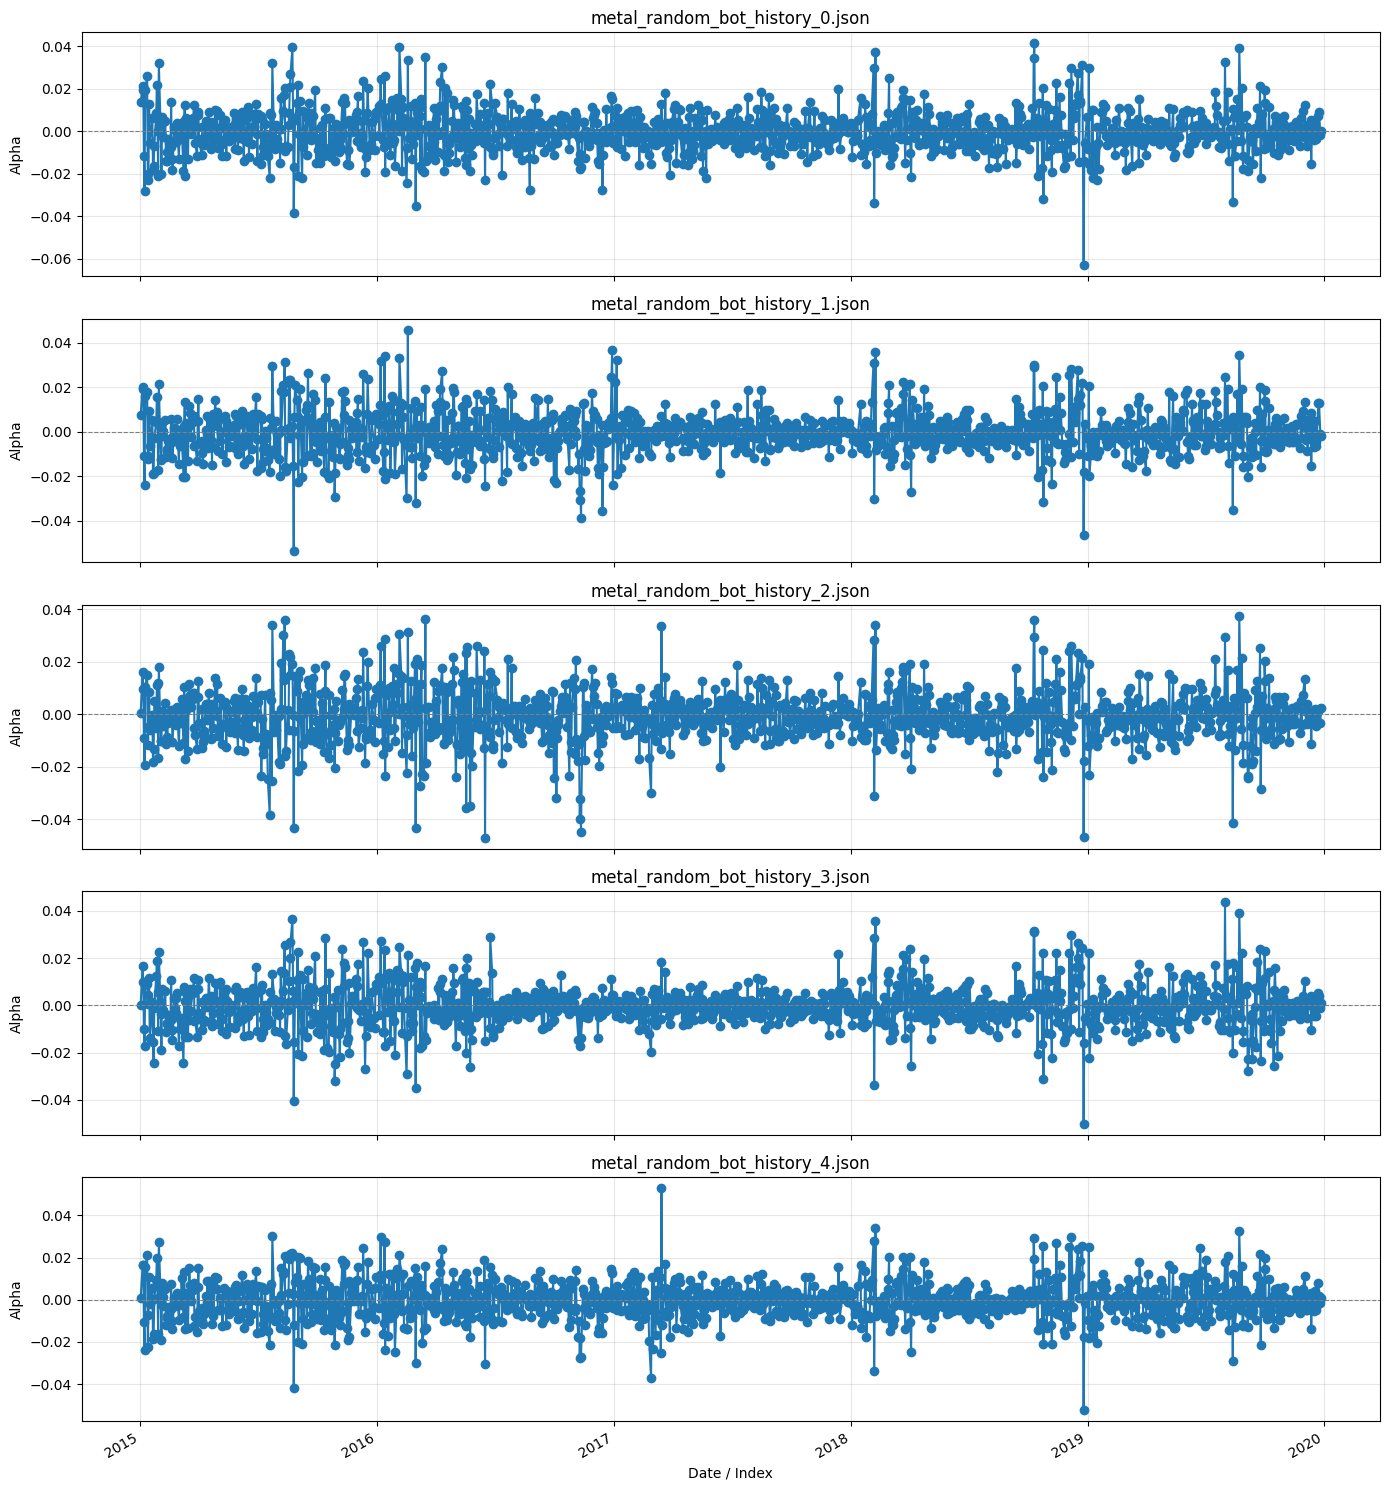

In [28]:
dataPaths = [
"data/random_bot_histories/metal_random_bot_history_0.json",
"data/random_bot_histories/metal_random_bot_history_1.json",
"data/random_bot_histories/metal_random_bot_history_2.json",
"data/random_bot_histories/metal_random_bot_history_3.json",
"data/random_bot_histories/metal_random_bot_history_4.json"
]
plot_data(dataPaths)